PROBLEM 

a) 1
b) 1
c) 1
d) 1
e) 2
f) 1
g) 1
h) 2 

We have modelled a protein structure. We need to asses this model
(Note: use more than one winsize of Prosa to detect the errors)

__a) What's the protein fold and family of this protein?__


`PDBtoSplitChain.pl -i problem_3 -o target`to obtain the `target1.fa` and `target1.pdb`file

To find the folds of the protein I'll use SCOP. As I don't have a name of the target protein, I'll do first a blast`to find the closest homolgs!

`blastp -query target1.fa  -db /mnt/NFS_UPF/soft/databases/blastdat/pdb_seq > blastp_close_homologs`

```
Length=314
                                                                      Score     E
Sequences producing significant alignments:                          (Bits)  Value

8cpa_A mol:protein length:307 CARBOXYPEPTIDASE A                      580     0.0   
7cpa_A mol:protein length:307 CARBOXYPEPTIDASE A                      580     0.0   
6cpa_A mol:protein length:307 CARBOXYPEPTIDASE A                      580     0.0   
5cpa_A mol:protein length:307 CARBOXYPEPTIDASE A                      580     0.0   
4cpa_B mol:protein length:307 CARBOXYPEPTIDASE A                      580     0.0   
4cpa_A mol:protein length:307 CARBOXYPEPTIDASE A                      580     0.0   
3cpa_A mol:protein length:307 CARBOXYPEPTIDASE A                      580     0.0   
1iy7_A mol:protein length:307 Carboxypeptidase A                      580     0.0   
1hee_E mol:protein length:307 CARBOXYPEPTIDASE A                      580     0.0   
1hee_D mol:protein length:307 CARBOXYPEPTIDASE A                      580     0.0   
1hee_B mol:protein length:307 CARBOXYPEPTIDASE A                      580     0.0   
1hee_A mol:protein length:307 CARBOXYPEPTIDASE A                      580     0.0   
1hdu_E mol:protein length:307 CARBOXYPEPTIDASE A                      580     0.0   
1hdu_D mol:protein length:307 CARBOXYPEPTIDASE A                      580     0.0   
1hdu_B mol:protein length:307 CARBOXYPEPTIDASE A                      580     0.0   
1hdu_A mol:protein length:307 CARBOXYPEPTIDASE A                      580     0.0   
1bav_D mol:protein length:309 CARBOXYPEPTIDASE A                      580     0.0   
1bav_C mol:protein length:309 CARBOXYPEPTIDASE A                      580     0.0   
1bav_B mol:protein length:309 CARBOXYPEPTIDASE A                      580     0.0   
1bav_A mol:protein length:309 CARBOXYPEPTIDASE A                      580     0.0  
```
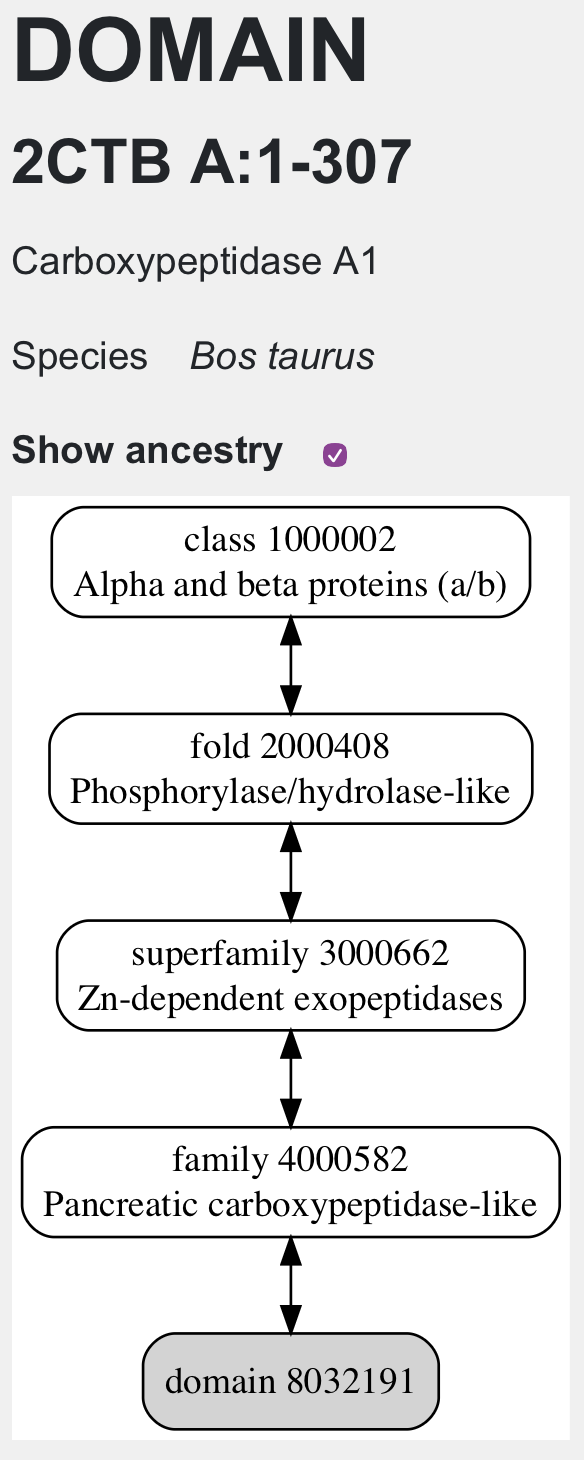

On SCOP I found that this protein belongs to the `Carboxipeptidase A1`family and the fold is `Phosphorylase/hydrolase-like`.

__b) Obtain the HMM profile for this family and align it with the closest homolog. Keep the HMM profile as p3b.hmm and the alignment as p3b.aln__

I need to fetch the HMM from the Pfam db 

`hmmfetch /mnt/NFS_UPF/soft/databases/pfam-3/Pfam-A.hmm Peptidase_M14 > p3b.hmm`

It is searched the Peptidase_M14 profile because in the blast results all are carboxypeptidase_A and search it in the `PDB` web page, in the `Annotations section` > `Domain Annotation: ECOD Classification`we will see in the `Family Name`. But the best way is to do:

`hmmscan /mnt/NFS_UPF/soft/databases/pfam-3/Pfam-A.hmm target1.fa > targetpfam.out`

```
Query:       target1  [L=314]
Scores for complete sequence (score includes all domains):
   --- full sequence ---   --- best 1 domain ---    -#dom-
    E-value  score  bias    E-value  score  bias    exp  N  Model         Description
    ------- ------ -----    ------- ------ -----   ---- --  --------      -----------
      5e-67  226.3   0.0    5.6e-67  226.1   0.0    1.0  1  Peptidase_M14  Zinc carboxypeptidase
```

Once have the hmm profile, align with `hmmalign` the chosen homolog `8cpa_A`to this `p3b.hmm` profile:

```
cp /mnt/NFS_UPF/soft/databases/pdb/pdb/data/structures/divided/pdb/cp/pdb8cpa.ent.gz .
cp /mnt/NFS_UPF/soft/databases/pdb/pdb/data/structures/divided/pdb/he/pdb1hee.ent.gz .
cp /mnt/NFS_UPF/soft/databases/pdb/pdb/data/structures/divided/pdb/hd/pdb1hdu.ent.gz .

gunzip *.gz

PDBtoSplitChain.pl -i pdb8cpa.ent -o 8cpa_
PDBtoSplitChain.pl -i pdb1hdu.ent -o 1hdu_
PDBtoSplitChain.pl -i pdb1hee.ent -o 1hee_

cat 8cpa_A.fa > alignment.fa
cat 1hdu_E.fa >> alignment.fa 
cat 1hee_A.fa >> alignment.fa 
cat target1.fa >> alignment.fa

clustalw alignment.fa

aconvertMod2.pl -in c -out p < alignment.aln > alignment.pir

```

The previous code was done to run modeller in order to obtain a prediciton of our modell. Because if we only take into accout the `pdb`file of the target just by doing `PDBtoSplitChain.pl`then will obtian a spaguetty conformatio, and that does not give structural information!!! So will use the prediction that has the higher score:

```
>> Summary of successfully produced models:
Filename                          molpdf
----------------------------------------
target1.B99990001.pdb         9925.02539
target1.B99990002.pdb         9970.28711

```
`mv target1.B99990002.pdb target.pdb`

Once have the model, now yes, align the hmm profile from pfam with one homolog as shown here:

```
hmmalign p3b.hmm 8cpa_A.fa > p3b.aln
```

This will show exactly how `8CPA_A`fits into the general "rules" of the M14 family

```
8cpa_A         arstntfnyatyhtldeIYDFMDLLVAQHPELVSKLQIGRSYEGRPIYVLKFSTG----GSNRPAIWIDLGIHSREWITQATGVWFAKKFTENYgQNPSFTAILDSMDIFLEIVTNPNGFAFTHSENRLWRKTRSVTSsslcvGVDANRNWDAGFGKAGASSSPCSETYHGKYANSEVEVKSIVDFVKNhGNFKAFLSIH
#=GR 8cpa_A PP *****************679**********************************9....8***************************************************************************999************************************************7666**********
#=GC PP_cons   .................679**********************************9....8**********************************.****************************************999.....*******************************************766.**********
#=GC RF        .................xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx.xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx.....xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx.xxxxxxxxxx

8cpa_A         SYSQLLLYPYGYTT-QSIPDKTELNQVAKSAVAALKS-LYGTSY-KYG-SIITTIYQASGGSIDWSY-NQGIKYSFTFELRDTGRygFLLPASQIIPTAQETWL-gvltimehtvnn
#=GR 8cpa_A PP **************.********************99.999***.***.55556*************.78999*****************************96.7***********
#=GC PP_cons   **************.********************99.999***.***.55556*************.78999************..***************96.............
#=GC RF        xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx..xxxxxxxxxxxxxxxxxx............
//
```

There are highly conserved regions `*` and also _capital letters_ 

__c) To perform the natural function of this protein it's usually required a cation. Add the cation that you think more convenient in this structure and name the PDB as p3c.pdb__

Manually add the zinc ion into the active site of the `target.pdb`file. Since Carboxypeptidase A is a metalloenzyme, it cannot perform its catalytic function without this cation. For that, "steal" the coordinates from the closest homolog (like 3CPA or 5CPA). To do so:

1. Open your model and the homolog (template) in Chimera --> `chimera target.pdb pdb8cpa.ent`

2. Superimpose them as you did before (Tools -> Structure Comparison -> MatchMaker).

3. Go to File -> Save PDB.

4. In the save dialog:

- Select ONLY the homolog (the one that has the Zinc).

- Crucial: Check the box that says "Save relative to [Your Model Name]".

- Save this as p3c_copy.pdb.

5.  Now, open p3c_copy.pdb in a text editor. The (x,y,z) coordinates for the Zinc in this new file have been mathematically "moved" to match your model's coordinate system.

6. Copy the HETATM line from this new file into your p3c.pdb.

- `grep "^HETATM.*ZN" p3c_copy.pdb >> p3c.pdb`

- `echo "END" >> target.pdb`

If we visualize on chimera `target1.pdb`we would get:

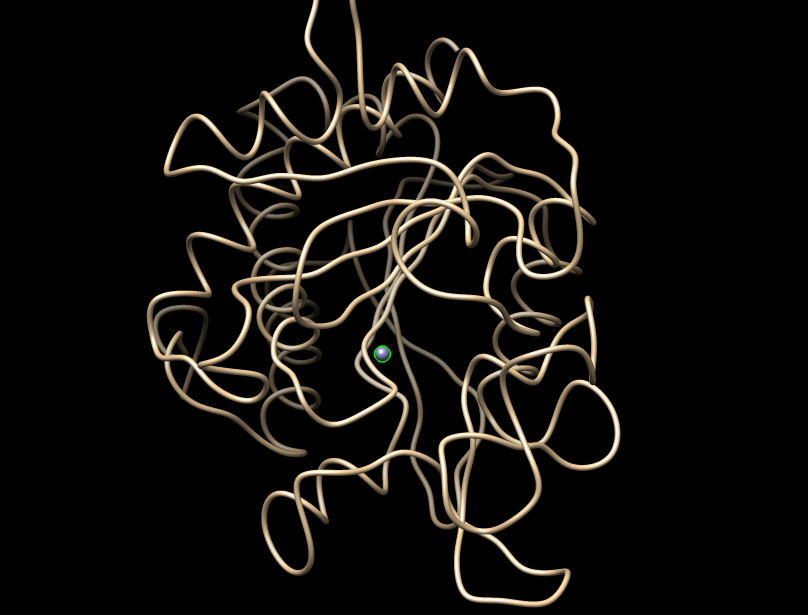

Since you only have one atom per residue (the Cα), the software creates a simple polygonal line connecting CA1→CA2→CA3. It lacks the "flesh" (side chains) and the "skeleton" (backbone N,C,O atoms) that give a protein its usual bulky, structured look.

But, if we open `chimera p3c.pdb`then it shows a full structure predicted model of our target. 

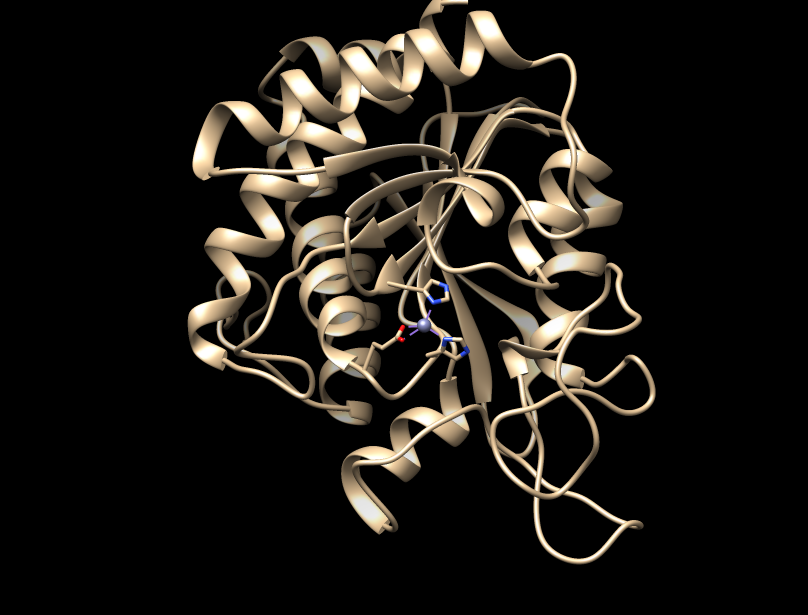

__d) Show with a symbol @ in the alignment (in p3b.aln) the residues that you think are important for the function__

Since I have already identified that this protein is a Carboxypeptidase A, I must now "mark" the speciic amino acids in the alignment that are responsible for holding that Zinc ion and performing the catalysis. 

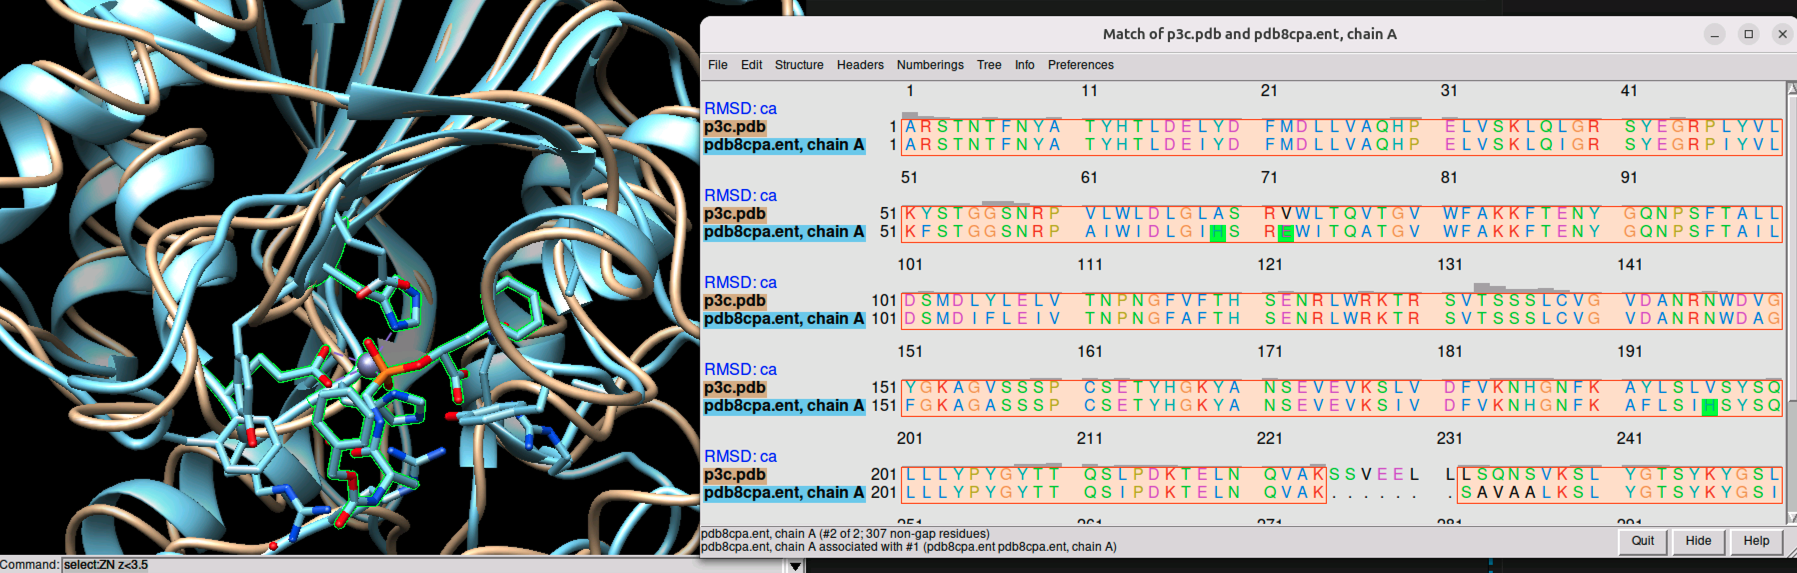

If we open chimera, superimpose the template with the targe, select the residue zn, and `select: ZN<3.5`It will show me the residues interacting witht the zinc moleucle and also its positions:

- H: 69
- E: 72
- H: 196

This 3 residues physically hold the ZN ion in place. Besides your H69, E72, and H196, you need to find and mark these with the @ symbol:

- Arg-145 (R): This residue coordinates the carboxylate group of the substrate. It is crucial for positioning the protein you are trying to "cut."

- Tyr-248 (Y): This is one of the most famous residues in this protein. It undergoes a large conformational change to "close" the active site once the substrate enters.

- Glu-270 (E): This residue acts as the general base/acid catalyst that helps the water molecule attack the peptide bond.

ON chimera `select :69,72,145,196,248,270`

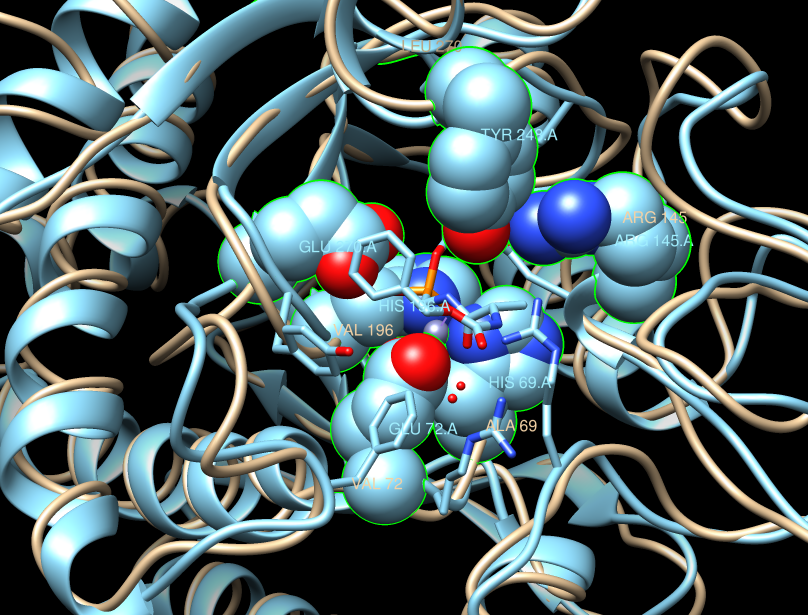

e) Show with an image of the structure of the active site (p3e_fig1) the relevant residues 
   for the function and if they are preserved or not. Plese select an image of the active site indicating if the residues
   are preserved, NOT an image of the whole structure.
   Do you think this protein is active?

f) Could you please confirm that all regions are OK?.
   If there is some region wrongly modelled, can you please indicate it?
   In order to show this, you can use a maximium of 3 images.
   Please name them  p3f_fig1, p3f_fig2, and p3f_fig3 and write the legends
   in the text file with the answers.

g) What do you think is the problem? Calculate the secondary structure
   and name the DSSP file as  p3b.dssp
   In order to show this you can use 2 images or text files.
   Please name them  p3g_fig1,p3g_fig2.

h) Fix the problem. To show that the problem is solved you can use a maximum
   of 2 images. Please name them p3h_fig1 i p3h_fig2 and write the legends
   in the text file of the exam.
   Name the coordinates file of the fixed model p3h.pdb with the functional cation.